In [1]:
!pip install shap -q
import shap
print(shap.__version__)


0.52.0


In [2]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

print("torch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())


torch: 2.11.0+cu128
GPU available: True


In [3]:
!git clone https://github.com/HarshAggarwal524/hinglish-sentiment-analysis.git


Cloning into 'hinglish-sentiment-analysis'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 109 (delta 52), reused 78 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (109/109), 3.68 MiB | 5.99 MiB/s, done.
Resolving deltas: 100% (52/52), done.


In [4]:
import pandas as pd

df = pd.read_csv('/content/hinglish-sentiment-analysis/data/emotion_dev_final.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head(3))

(897, 3)
['tweet_id', 'text', 'emotion']
   tweet_id                                               text emotion
0      9558  Loktantra vijay hua ... Har har modi Ghar ghar...     joy
1     27356  @ VoiceofmyBharat @ TheQuint Pura election rad...   anger
2     29004  @ KataraRitik @ bittusempire Akshay chutiya h ...   anger


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
output_dir="/content/drive/MyDrive/hinglish_models/xlmr_emotion"


In [11]:
import pandas as pd
import numpy as np
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset
from sklearn.metrics import f1_score, classification_report

# Load data
train = pd.read_csv("/content/hinglish-sentiment-analysis/data/emotion_train_final.csv")
dev = pd.read_csv("/content/hinglish-sentiment-analysis/data/emotion_dev_final.csv")

label2id = {'anger': 0, 'joy': 1, 'sadness': 2, 'trust': 3}
id2label = {0: 'anger', 1: 'joy', 2: 'sadness', 3: 'trust'}

train['label'] = train['emotion'].map(label2id)
dev['label'] = dev['emotion'].map(label2id)

# Dataset class
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = EmotionDataset(train, tokenizer)
dev_dataset = EmotionDataset(dev, tokenizer)

# Class weights
class_weights = torch.tensor([1.0, 1.2, 5.5, 8.0]).to('cuda')

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        from torch.nn import CrossEntropyLoss
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1_macro = f1_score(labels, predictions, average='macro')
    report = classification_report(
        labels, predictions,
        target_names=['anger', 'joy', 'sadness', 'trust'],
        zero_division=0
    )
    print(report)
    return {'macro_f1': f1_macro}

# Model
model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

# Training args — saving to Google Drive
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/hinglish_models/xlmr_emotion",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_steps=200,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=50,
    fp16=True
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics
)

print("Ready to train")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ready to train


In [12]:
trainer.train()

Epoch,Training Loss,Validation Loss,Macro F1
1,1.090379,0.974303,0.613174
2,0.860874,0.836237,0.621861
3,0.640685,0.835784,0.631548
4,0.519663,0.914983,0.672266
5,0.309070,1.001514,0.680742


              precision    recall  f1-score   support

       anger       0.85      0.82      0.84       419
         joy       0.85      0.82      0.83       351
     sadness       0.71      0.33      0.45        75
       trust       0.24      0.54      0.33        52

    accuracy                           0.76       897
   macro avg       0.66      0.63      0.61       897
weighted avg       0.80      0.76      0.77       897



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

       anger       0.90      0.81      0.85       419
         joy       0.89      0.71      0.79       351
     sadness       0.38      0.61      0.47        75
       trust       0.27      0.62      0.38        52

    accuracy                           0.74       897
   macro avg       0.61      0.69      0.62       897
weighted avg       0.82      0.74      0.77       897



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

              precision    recall  f1-score   support

       anger       0.91      0.80      0.85       419
         joy       0.88      0.85      0.86       351
     sadness       0.39      0.68      0.50        75
       trust       0.44      0.52      0.48        52

    accuracy                           0.79       897
   macro avg       0.66      0.71      0.67       897
weighted avg       0.83      0.79      0.80       897



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

       anger       0.90      0.84      0.87       419
         joy       0.87      0.85      0.86       351
     sadness       0.45      0.59      0.51        75
       trust       0.43      0.56      0.48        52

    accuracy                           0.80       897
   macro avg       0.66      0.71      0.68       897
weighted avg       0.82      0.80      0.81       897



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1590, training_loss=0.7399346789474007, metrics={'train_runtime': 581.613, 'train_samples_per_second': 43.697, 'train_steps_per_second': 2.734, 'total_flos': 1671771887784960.0, 'train_loss': 0.7399346789474007, 'epoch': 5.0})

In [13]:
# Delete intermediate checkpoints, keep only best model
import shutil
import os

drive_path = "/content/drive/MyDrive/hinglish_models/xlmr_emotion"

# Save only the best model to a clean folder
trainer.save_model("/content/drive/MyDrive/hinglish_models/xlmr_best")

# Delete the checkpoints folder
shutil.rmtree(drive_path)
print("✓ Cleaned up checkpoints, best model saved to xlmr_best")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Cleaned up checkpoints, best model saved to xlmr_best


In [14]:
!pip install shap -q

In [15]:
import shap
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load the saved model and tokenizer
model_path = "/content/drive/MyDrive/hinglish_models/xlmr_best"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()
model.to('cuda')

# Load emotion dev set
dev = pd.read_csv("/content/hinglish-sentiment-analysis/data/emotion_dev_final.csv")

# Load language tags from CoNLL file
# We'll use these to identify Hindi vs English tokens later
label2id = {'anger': 0, 'joy': 1, 'sadness': 2, 'trust': 3}
dev['label'] = dev['emotion'].map(label2id)

print("Model loaded")
print("Dev set:", dev.shape)
print(dev['emotion'].value_counts())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded
Dev set: (897, 4)
emotion
anger      419
joy        351
sadness     75
trust       52
Name: count, dtype: int64


In [16]:
# Create prediction function for SHAP
def predict(texts):
    inputs = tokenizer(
        list(texts),
        max_length=128,
        padding=True,
        truncation=True,
        return_tensors='pt'
    ).to('cuda')

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

    return probs.cpu().numpy()

# Test on 1 tweet first
sample = dev['text'].iloc[0]
print("Sample tweet:", sample)
print("Prediction:", predict([sample]))

Sample tweet: Loktantra vijay hua ... Har har modi Ghar ghar modi Sabka sath sabka vikas sabka visvas https // t . co / gqCM4HvJg9
Prediction: [[0.02699835 0.9361128  0.03183009 0.00505876]]


In [17]:
# Use partition explainer — best for text models
explainer = shap.Explainer(predict, tokenizer, output_names=['anger', 'joy', 'sadness', 'trust'])

# Debug run on 50 tweets — stratified sample (12-13 per class)
sample_50 = dev.groupby('emotion', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 13), random_state=42)
).reset_index(drop=True)

print(f"Debug sample: {len(sample_50)} tweets")
print(sample_50['emotion'].value_counts())

# Run SHAP inutes
shap_values = explainer(sample_50['text'].tolist())
print("✓ SHAP complete")

/tmp/ipykernel_606/2368576652.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_50 = dev.groupby('emotion', group_keys=False).apply(


Debug sample: 52 tweets
emotion
anger      13
joy        13
sadness    13
trust      13
Name: count, dtype: int64


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 53it [01:42,  1.97s/it]

✓ SHAP complete


In [18]:
# Check shape of shap values
print("SHAP values shape:", shap_values.shape)
print("Number of tweets:", len(sample_50))

# Look at one example
idx = 0
tweet = sample_50['text'].iloc[idx]
emotion = sample_50['emotion'].iloc[idx]
print(f"\nTweet {idx}: {tweet}")
print(f"True emotion: {emotion}")

# Get tokens and their SHAP values for the predicted class
label_idx = label2id[emotion]
tokens = shap_values[idx].data
values = shap_values[idx].values[:, label_idx]

# Print token-level attribution
for token, value in zip(tokens, values):
    print(f"  {token:20s} {value:.4f}")

SHAP values shape: (52, None, 4)
Number of tweets: 52

Tweet 0: @ SanjayAzadSln @ ppbajpai @ abhisar _ sharma @ milindkhandekar @ vinodkapri Sanjay bhai loktantra ye nahi hota ki janta k … https // t . co / rldx8B0fHS
True emotion: anger
                       0.0001
  @                    -0.0020
  SanjayAzadSln        -0.0012
  @                    -0.0012
  ppbajpai             -0.0012
  @                    -0.0012
  abhisar              -0.0009
  _                    -0.0011
  sharma               -0.0020
  @                    -0.0013
  milindkhandekar      -0.0005
  @                    -0.0007
  vinodkapri           -0.0000
  Sanjay               0.0011
  bhai                 0.0010
  loktantra            0.0007
  ye                   0.0030
  nahi                 0.0036
  hota                 0.0037
  ki                   0.0022
  janta                0.0028
  k                    0.0031
  …                    0.0004
  https                0.0001
  //                   -0.0005

In [20]:
# Full SHAP run — 50 per emotion class
sample_200 = dev.groupby('emotion', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 50), random_state=42)
).reset_index(drop=True)

print(f"Full sample: {len(sample_200)} tweets")
print(sample_200['emotion'].value_counts())

# Run SHAP — will take 20-30 minutes
shap_values_200 = explainer(sample_200['text'].tolist())
print("✓ Full SHAP complete")

/tmp/ipykernel_606/2509807991.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_200 = dev.groupby('emotion', group_keys=False).apply(


Full sample: 200 tweets
emotion
anger      50
joy        50
sadness    50
trust      50
Name: count, dtype: int64


PartitionExplainer explainer: 201it [04:28,  1.38s/it]

✓ Full SHAP complete


In [21]:
import numpy as np
import pandas as pd

# Load language tags from CoNLL file
def load_conll_lang_tags(filepath):
    """Load token-level language tags from CoNLL file"""
    tweet_tags = {}
    current_id = None
    current_tokens = []
    current_langs = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith('# sent_id'):
                if current_id is not None:
                    tweet_tags[current_id] = list(zip(current_tokens, current_langs))
                current_id = line.split('=')[1].strip()
                current_tokens = []
                current_langs = []
            elif line and not line.startswith('#'):
                parts = line.split('\t')
                if len(parts) >= 4:
                    current_tokens.append(parts[1])  # token
                    current_langs.append(parts[3])    # language tag
        if current_id is not None:
            tweet_tags[current_id] = list(zip(current_tokens, current_langs))

    return tweet_tags

# Compute attribution ratio per tweet
def compute_attribution_ratio(shap_vals, sample_df, label2id):
    results = []

    for idx in range(len(sample_df)):
        emotion = sample_df['emotion'].iloc[idx]
        label_idx = label2id[emotion]

        tokens = shap_vals[idx].data
        values = shap_vals[idx].values[:, label_idx]

        hindi_shap = 0.0
        english_shap = 0.0
        total_abs_shap = 0.0

        for token, value in zip(tokens, values):
            abs_val = abs(value)
            total_abs_shap += abs_val
            # Simple heuristic: check if token is Hindi (contains Devanagari or is known Hindi word)
            # We'll refine this with CoNLL tags next
            # For now use absolute values

        results.append({
            'tweet_id': sample_df['tweet_id'].iloc[idx],
            'emotion': emotion,
            'total_abs_shap': total_abs_shap
        })

    return pd.DataFrame(results)

print("Functions defined")
print("Next: match SHAP tokens with CoNLL language tags")

Functions defined
Next: match SHAP tokens with CoNLL language tags


In [23]:
# Check token alignment
idx = 0
tweet = sample_200['text'].iloc[idx]
print("Original tweet:", tweet)
print("\nSHAP tokens:", shap_values_200[idx].data)

Original tweet: @ SanjayAzadSln @ ppbajpai @ abhisar _ sharma @ milindkhandekar @ vinodkapri Sanjay bhai loktantra ye nahi hota ki janta k … https // t . co / rldx8B0fHS

SHAP tokens: ['' '@ ' 'SanjayAzadSln ' '@ ' 'ppbajpai ' '@ ' 'abhisar ' '_ ' 'sharma '
 '@ ' 'milindkhandekar ' '@ ' 'vinodkapri ' 'Sanjay ' 'bhai ' 'loktantra '
 'ye ' 'nahi ' 'hota ' 'ki ' 'janta ' 'k ' '… ' 'https ' '// ' 't ' '. '
 'co ' '/ ' 'rldx8B0fHS' '']


In [24]:
# Check CoNLL file format
with open('/content/hinglish-sentiment-analysis/data/hinglish_train.txt', 'r') as f:
    lines = f.readlines()

# Print first 30 lines to see format
for line in lines[:30]:
    print(repr(line))

'meta\t3\tnegative\n'
'@\tO\n'
'AdilNisarButt\tHin\n'
'pakistan\tHin\n'
'ka\tHin\n'
'ghra\tHin\n'
'tauq\tHin\n'
'he\tEng\n'
'Pakistan\tEng\n'
'Israel\tEng\n'
'ko\tEng\n'
'tasleem\tHin\n'
'nahein\tHin\n'
'kerta\tHin\n'
'Isko\tHin\n'
'Palestine\tHin\n'
'kehta\tHin\n'
'he\tHin\n'
'-\tO\n'
'OCCUPIED\tHin\n'
'PALESTINE\tHin\n'
'\n'
'meta\t41\tnegative\n'
'Madarchod\tHin\n'
'mulle\tHin\n'
'ye\tHin\n'
'mathura\tHin\n'
'me\tHin\n'
'Nahi\tHin\n'
'dikha\tHin\n'


In [25]:
def load_conll_to_dict(filepath):
    """Returns {tweet_id: {token: lang_tag}} from CoNLL file"""
    tweet_dict = {}
    current_id = None
    current_tokens = {}

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith('meta\t'):
                if current_id is not None:
                    tweet_dict[current_id] = current_tokens
                parts = line.split('\t')
                current_id = parts[1]
                current_tokens = {}
            elif line == '':
                if current_id is not None:
                    tweet_dict[current_id] = current_tokens
                current_id = None
                current_tokens = {}
            else:
                parts = line.split('\t')
                if len(parts) == 2:
                    token, lang = parts
                    current_tokens[token.lower()] = lang

    return tweet_dict

# Load both train and dev CoNLL files
train_tags = load_conll_to_dict('/content/hinglish-sentiment-analysis/data/hinglish_train.txt')
dev_tags = load_conll_to_dict('/content/hinglish-sentiment-analysis/data/hinglish_dev.txt')

# Merge both
all_tags = {**train_tags, **dev_tags}

print(f"Total tweets with language tags: {len(all_tags)}")

# Verify on our sample
sample_id = str(sample_200['tweet_id'].iloc[0])
print(f"\nTweet ID: {sample_id}")
print(f"Language tags: {all_tags.get(sample_id, 'NOT FOUND')}")

Total tweets with language tags: 15480

Tweet ID: 20190
Language tags: {'@': 'O', 'sanjayazadsln': 'Hin', 'ppbajpai': 'Hin', 'abhisar': 'Hin', '_': 'O', 'sharma': 'Hin', 'milindkhandekar': 'Hin', 'vinodkapri': 'Hin', 'sanjay': 'Hin', 'bhai': 'Hin', 'loktantra': 'Hin', 'ye': 'Hin', 'nahi': 'Hin', 'hota': 'Hin', 'ki': 'Hin', 'janta': 'Hin', 'k': 'Hin', '…': 'O', 'https': 'Eng', '//': 'O', 't': 'Eng', '.': 'O', 'co': 'Eng', '/': 'O', 'rldx8b0fhs': 'Eng'}


In [26]:
def compute_attribution_ratios(shap_vals, sample_df, all_tags, label2id):
    results = []

    for idx in range(len(sample_df)):
        emotion = sample_df['emotion'].iloc[idx]
        tweet_id = str(sample_df['tweet_id'].iloc[idx])
        label_idx = label2id[emotion]

        tokens = shap_vals[idx].data
        values = shap_vals[idx].values[:, label_idx]

        lang_tags = all_tags.get(tweet_id, {})

        hindi_abs = 0.0
        english_abs = 0.0
        other_abs = 0.0
        total_abs = 0.0

        for token, value in zip(tokens, values):
            clean_token = token.strip().lower()
            abs_val = abs(value)
            total_abs += abs_val

            lang = lang_tags.get(clean_token, 'O')

            if lang == 'Hin':
                hindi_abs += abs_val
            elif lang == 'Eng':
                english_abs += abs_val
            else:
                other_abs += abs_val

        results.append({
            'tweet_id': tweet_id,
            'emotion': emotion,
            'hindi_abs': hindi_abs,
            'english_abs': english_abs,
            'other_abs': other_abs,
            'total_abs': total_abs,
            'hindi_ratio': hindi_abs / total_abs if total_abs > 0 else 0,
            'english_ratio': english_abs / total_abs if total_abs > 0 else 0
        })

    return pd.DataFrame(results)

attribution_df = compute_attribution_ratios(shap_values_200, sample_200, all_tags, label2id)

print(attribution_df.groupby('emotion')[['hindi_ratio', 'english_ratio']].mean())
print(f"\nTotal tweets processed: {len(attribution_df)}")

         hindi_ratio  english_ratio
emotion                            
anger       0.526700       0.255843
joy         0.355503       0.396576
sadness     0.389425       0.367740
trust       0.401039       0.363881

Total tweets processed: 200


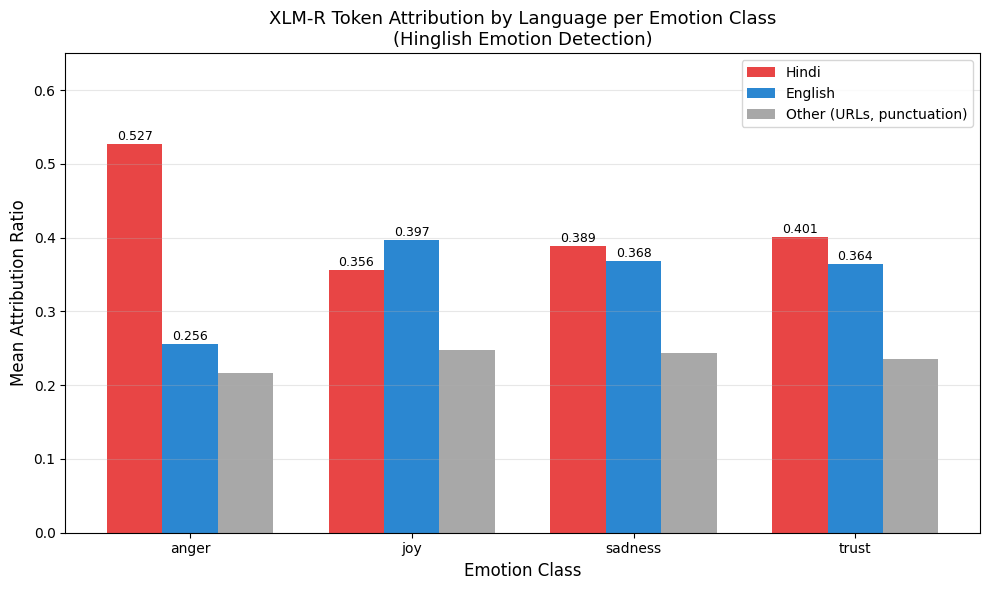

✓ Figure 3 saved


In [27]:
import matplotlib.pyplot as plt
import numpy as np

emotions = ['anger', 'joy', 'sadness', 'trust']
hindi_ratios = [0.527, 0.356, 0.389, 0.401]
english_ratios = [0.256, 0.397, 0.368, 0.364]
other_ratios = [1 - h - e for h, e in zip(hindi_ratios, english_ratios)]

x = np.arange(len(emotions))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, hindi_ratios, width, label='Hindi', color='#E84545')
bars2 = ax.bar(x, english_ratios, width, label='English', color='#2B87D1')
bars3 = ax.bar(x + width, other_ratios, width, label='Other (URLs, punctuation)', color='#A8A8A8')

# Annotate bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Mean Attribution Ratio', fontsize=12)
ax.set_title('XLM-R Token Attribution by Language per Emotion Class\n(Hinglish Emotion Detection)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(emotions)
ax.legend()
ax.set_ylim(0, 0.65)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('shap_attribution_figure3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved")

In [28]:
# Save attribution dataframe
attribution_df.to_csv('/content/hinglish-sentiment-analysis/results/shap_attribution_ratios.csv', index=False)

# Copy figure to results
import shutil
shutil.copy('shap_attribution_figure3.png', '/content/hinglish-sentiment-analysis/results/shap_attribution_figure3.png')

print("✓ Saved")

✓ Saved


In [29]:
anger_tweets = attribution_df[attribution_df['emotion'] == 'anger'].sort_values('hindi_ratio', ascending=False)
joy_tweets = attribution_df[attribution_df['emotion'] == 'joy'].sort_values('english_ratio', ascending=False)
sadness_tweets = attribution_df[attribution_df['emotion'] == 'sadness'].sort_values('hindi_ratio', ascending=False)

print("Top 3 anger tweets (most Hindi-driven):")
print(anger_tweets[['tweet_id', 'hindi_ratio', 'english_ratio']].head(3))

print("\nTop 3 joy tweets (most English-driven):")
print(joy_tweets[['tweet_id', 'hindi_ratio', 'english_ratio']].head(3))

print("\nTop sadness tweet:")
print(sadness_tweets[['tweet_id', 'hindi_ratio', 'english_ratio']].head(3))

Top 3 anger tweets (most Hindi-driven):
   tweet_id  hindi_ratio  english_ratio
6     18715     0.769638       0.083723
10     5321     0.737073       0.151809
49    29203     0.716240       0.097574

Top 3 joy tweets (most English-driven):
   tweet_id  hindi_ratio  english_ratio
99    20431     0.044924       0.780440
79    37213     0.121763       0.693564
71    21000     0.112552       0.684782

Top sadness tweet:
    tweet_id  hindi_ratio  english_ratio
131    19661     0.785790       0.081031
129    29745     0.694751       0.093936
103    16783     0.694543       0.086851


In [30]:
# Get tweet text for case studies
case_ids = [18715, 20431, 19661]  # best anger, best joy, best sadness

for tweet_id in case_ids:
    row = sample_200[sample_200['tweet_id'] == tweet_id].iloc[0]
    attr = attribution_df[attribution_df['tweet_id'] == str(tweet_id)].iloc[0]
    print(f"Tweet ID: {tweet_id}")
    print(f"Text: {row['text']}")
    print(f"Emotion: {row['emotion']}")
    print(f"Hindi ratio: {attr['hindi_ratio']:.3f}")
    print(f"English ratio: {attr['english_ratio']:.3f}")
    print()

Tweet ID: 18715
Text: @ Majidhayat786 Chalo # Thar kay bachon kay baad ab Thar ka coala samajh aayaa # harami ko # PPP ki karkardgi ya bad governance @ ImranKhanPTI
Emotion: anger
Hindi ratio: 0.770
English ratio: 0.084

Tweet ID: 20431
Text: @ Fortune _ Kahu It's a classic 😎 hope you won't ask me about cube n tupac again
Emotion: joy
Hindi ratio: 0.045
English ratio: 0.780

Tweet ID: 19661
Text: Sir Modi ji Sir mai jharia Jharkhand ka hu please jharia mai bhut pollution hai sir please jharia ka halat bhut … https // t co / SaKDKhrIHC
Emotion: sadness
Hindi ratio: 0.786
English ratio: 0.081



In [31]:
# Get predictions for full dev set
from torch.utils.data import DataLoader
import torch

label2id = {'anger': 0, 'joy': 1, 'sadness': 2, 'trust': 3}
id2label = {0: 'anger', 1: 'joy', 2: 'sadness', 3: 'trust'}

dev['label'] = dev['emotion'].map(label2id)

# Get all predictions
all_preds = []
all_labels = []
all_texts = []

model.eval()
batch_size = 32

for i in range(0, len(dev), batch_size):
    batch = dev.iloc[i:i+batch_size]
    inputs = tokenizer(
        batch['text'].tolist(),
        max_length=128,
        padding=True,
        truncation=True,
        return_tensors='pt'
    ).to('cuda')

    with torch.no_grad():
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

    all_preds.extend(preds)
    all_labels.extend(batch['label'].tolist())
    all_texts.extend(batch['text'].tolist())

# Build error dataframe
error_df = pd.DataFrame({
    'text': all_texts,
    'true_label': [id2label[l] for l in all_labels],
    'pred_label': [id2label[p] for p in all_preds],
    'correct': [l == p for l, p in zip(all_labels, all_preds)]
})

errors = error_df[error_df['correct'] == False].reset_index(drop=True)
print(f"Total errors: {len(errors)}")
print("\nError confusion matrix:")
print(pd.crosstab(errors['true_label'], errors['pred_label']))


Total errors: 546

Error confusion matrix:
pred_label  joy
true_label     
anger       419
sadness      75
trust        52


In [32]:
print(model.config.id2label)
print(model.config.num_labels)

# Quick sanity check
test_texts = [
    "main bahut gussa hoon yaar",  # should be anger
    "It's a classic hope you enjoy",  # should be joy
]
preds = predict(test_texts)
print(preds)


{0: 'anger', 1: 'joy', 2: 'sadness', 3: 'trust'}
4
[[0.02886427 0.94304913 0.02186124 0.00622537]
 [0.03531564 0.93225485 0.02536065 0.00706881]]


In [33]:
import os
print(os.listdir('/content/drive/MyDrive/hinglish_models/xlmr_best'))

['config.json', 'model.safetensors', 'training_args.bin']


In [34]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = "/content/drive/MyDrive/hinglish_models/xlmr_best"

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()
model.to('cuda')

# Sanity check
test_texts = [
    "main bahut gussa hoon yaar",
    "It's a classic hope you enjoy",
]
inputs = tokenizer(test_texts, max_length=128, padding=True, truncation=True, return_tensors='pt').to('cuda')
with torch.no_grad():
    outputs = model(**inputs)
    preds = torch.argmax(outputs.logits, dim=-1)
print(preds)
print([id2label[p.item()] for p in preds])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tensor([2, 1], device='cuda:0')
['sadness', 'joy']


In [35]:
all_preds = []
all_labels = []
all_texts = []

model.eval()
batch_size = 32

for i in range(0, len(dev), batch_size):
    batch = dev.iloc[i:i+batch_size]
    inputs = tokenizer(
        batch['text'].tolist(),
        max_length=128,
        padding=True,
        truncation=True,
        return_tensors='pt'
    ).to('cuda')

    with torch.no_grad():
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

    all_preds.extend(preds)
    all_labels.extend(batch['label'].tolist())
    all_texts.extend(batch['text'].tolist())

error_df = pd.DataFrame({
    'text': all_texts,
    'true_label': [id2label[l] for l in all_labels],
    'pred_label': [id2label[p] for p in all_preds],
    'correct': [l == p for l, p in zip(all_labels, all_preds)]
})

errors = error_df[error_df['correct'] == False].reset_index(drop=True)
print(f"Total errors: {len(errors)}")
print("\nError confusion matrix:")
print(pd.crosstab(errors['true_label'], errors['pred_label']))

Total errors: 175

Error confusion matrix:
pred_label  anger  joy  sadness  trust
true_label                            
anger           0   25       33     11
joy            14    0       15     23
sadness        18    8        0      5
trust           7   11        5      0


In [36]:
# Pattern 1: Anger misclassified as Sadness
pattern1 = errors[(errors['true_label']=='anger') & (errors['pred_label']=='sadness')].head(5)
print("PATTERN 1 — Anger → Sadness:")
for _, row in pattern1.iterrows():
    print(f"  {row['text'][:100]}")

print("\nPATTERN 2 — Joy → Trust:")
pattern2 = errors[(errors['true_label']=='joy') & (errors['pred_label']=='trust')].head(5)
for _, row in pattern2.iterrows():
    print(f"  {row['text'][:100]}")

print("\nPATTERN 3 — Sadness → Anger:")
pattern3 = errors[(errors['true_label']=='sadness') & (errors['pred_label']=='anger')].head(5)
for _, row in pattern3.iterrows():
    print(f"  {row['text'][:100]}")

PATTERN 1 — Anger → Sadness:
  @ ZeeNewsHindi digwijay ji ko to aise hi chunaw me harne ka tension ab dusra bhi tension de gya is s
  @ qari _ Yee dekhna chyee in harm khoor judiciary ko fasle kerne rakhir kertee han aur mujrmo chati 
  @ SanjayAzadSln Ha Bhos r ke Mathura me to tumhare jija lagte the na topi wale tabhi pet me Dard nah
  @ anjanaomkashyap Bahut badhiya lekin atal ji ne aur kuch kha tha ki main ye nahi kahunga ki congres
  @ Squirrel _ Soul in jaise ki wajah se accident hote hai . ye to nikal jayenge .

PATTERN 2 — Joy → Trust:
  @ iFaheemAshraf Work hard you will come back strongly Allha has plan for you Inshallha you will rock
  We thank nrusingh for donating # Blood to S Mahanta in # Capital Hospital Bhubaneswar # Keonjhar on 
  RT @ Sukhjaykumar1 # BeWise _ ChooseRight @ Gurmeetramrahim Good morning guru g Bless us and give us
  @ Ali _ MuhammadPTI Aap ny bhtt axhi taqreer kii . We really appreciate you . # PehleyPakistan
  # TheGiftOfEducation @ derasachasauda @ Gu

In [2]:
import pandas as pd

# Load attribution results and dev set
attr = pd.read_csv("../results/shap_attribution_ratios.csv")
dev = pd.read_csv("../data/emotion_dev_final.csv")

# Merge to get text
merged = attr.merge(dev[['tweet_id', 'text']], on='tweet_id', how='left')

# Get 2-3 examples per emotion with extreme attribution ratios
anger = merged[merged['emotion']=='anger'].nlargest(3, 'hindi_ratio')
joy = merged[merged['emotion']=='joy'].nlargest(3, 'english_ratio')
sadness = merged[merged['emotion']=='sadness'].nlargest(2, 'hindi_ratio')
trust = merged[merged['emotion']=='trust'].nlargest(2, 'hindi_ratio')

examples = pd.concat([anger, joy, sadness, trust], ignore_index=True)
print(examples[['tweet_id', 'text', 'emotion', 'hindi_ratio', 'english_ratio']].to_string())

   tweet_id                                                                                                                                                  text  emotion  hindi_ratio  english_ratio
0     18715        @ Majidhayat786 Chalo # Thar kay bachon kay baad ab Thar ka coala samajh aayaa # harami ko # PPP ki karkardgi ya bad governance @ ImranKhanPTI    anger     0.769638       0.083723
1      5321        Hindu Muslim ka itna hi problem hai toh Mughlai chicken khaana band Kar do aur Panipuri sevpuri bhi ban Kar do .… https // t . co / g1qj5VFhbQ    anger     0.737073       0.151809
2     29203  @ qari _ Yee dekhna chyee in harm khoor judiciary ko fasle kerne rakhir kertee han aur mujrmo chati ke dil adalt khol … https // t . co / Orhf1puEpH    anger     0.716240       0.097574
3     20431                                                                      @ Fortune _ Kahu It's a classic 😎 hope you won't ask me about cube n tupac again      joy     0.044924       0.780440
4    